# Where is it cheap to travel right now?

A weak foreign currency does not by itself make a country cheap — local prices usually rise
along with the exchange rate. This notebook combines IMF exchange rates, IMF CPI, World Bank
PPP factors, and State Dept. advisories into one metric: **the number of current US dollars
needed abroad to buy what $1 buys in the US**. Below 1.0 means a dollar goes further there.

See `README.md` for the reasoning and `src/real_travel_cost/` for the implementation.

In [1]:
import real_travel_cost as rtc

rtc.use_style()

# First call fetches from the IMF and caches; pass refresh=True to refetch.
panel = rtc.load_panel()
panel.tail()

,country_code,date,cpi,exr,country_name,ppp,advisory_level,cpi_rebased,ppp_dollars,real_dollars,us_cpi,current_dollars
42409,ZWE,2023-04-01,280.484590,1047.4449,Zimbabwe,22.01,2,539.229526,0.021013,11.330851,117.214031,0.096668
42410,ZWE,2023-05-01,324.632817,2577.0564,Zimbabwe,22.01,2,624.104162,0.008541,5.330319,117.509226,0.045361
42411,ZWE,2023-06-01,566.355983,5739.7961,Zimbabwe,22.01,2,1088.815140,0.003835,4.175204,117.888654,0.035417
42412,ZWE,2023-07-01,479.966999,4516.8025,Zimbabwe,22.01,2,922.732965,0.004873,4.496400,118.113528,0.038068
42413,ZWE,2023-08-01,450.428524,4608.1066,Zimbabwe,22.01,2,865.945468,0.004776,4.136072,118.629348,0.034866


## Cost of living over time

<Axes: title={'left': 'Cost of living in current US dollars'}>

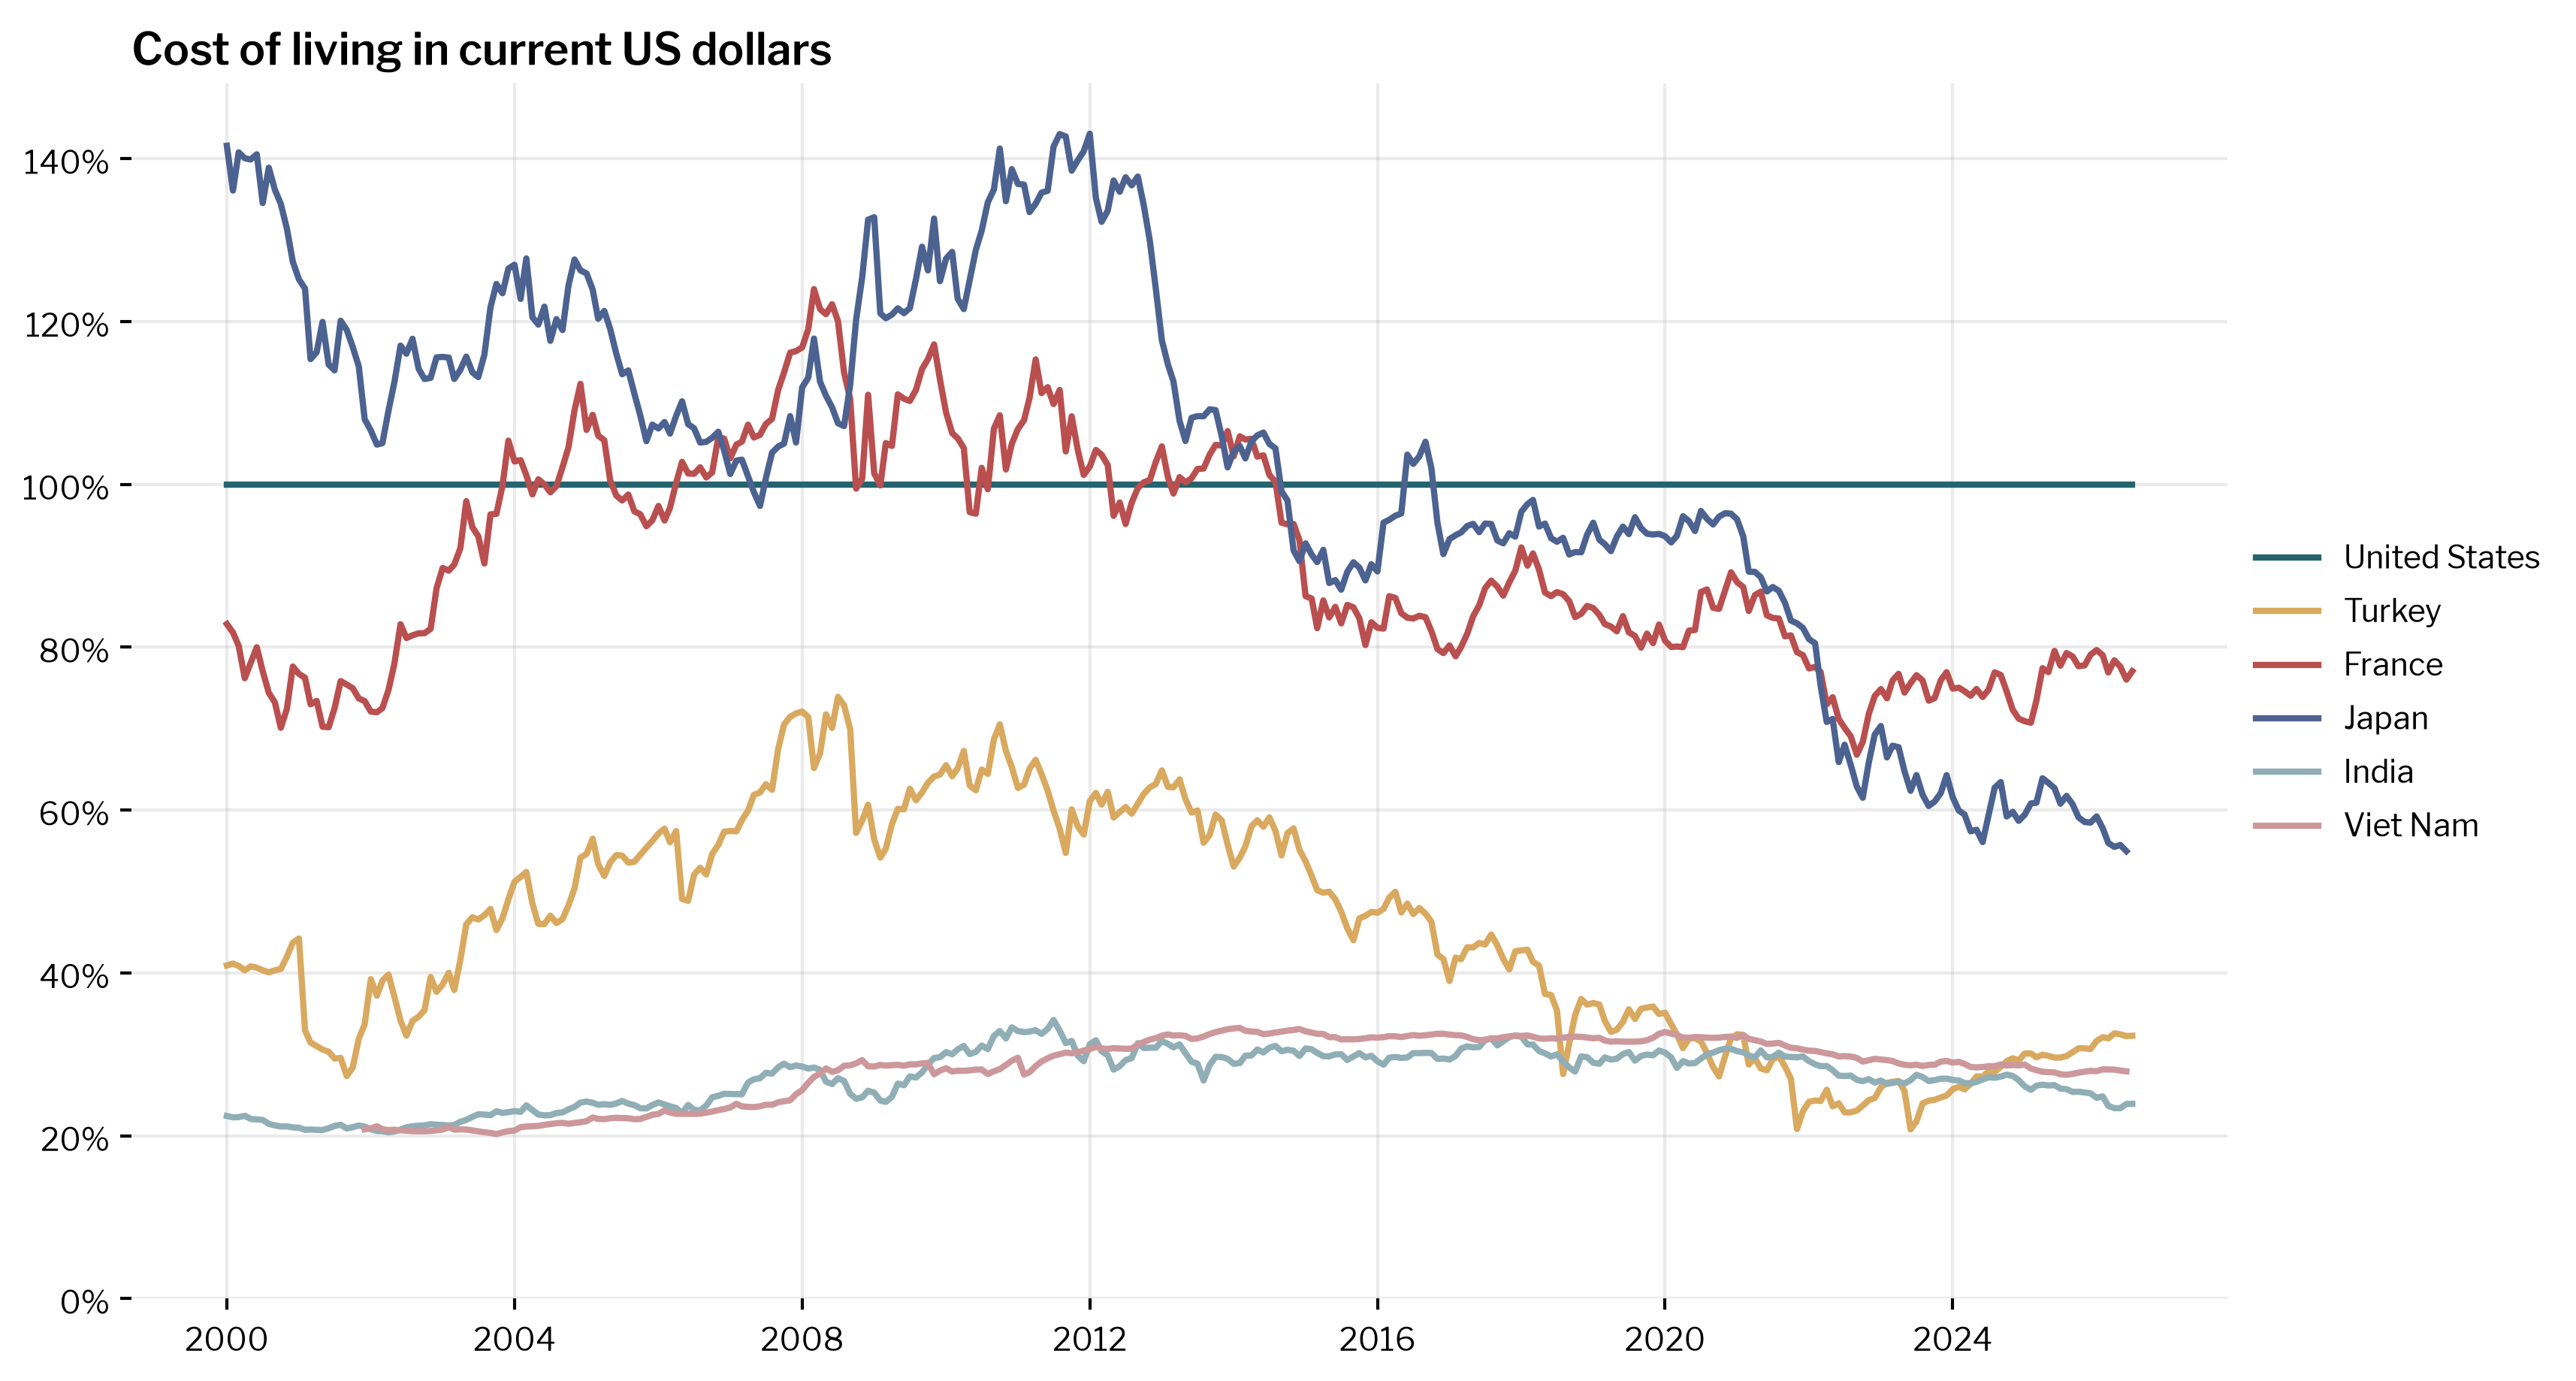

In [2]:
rtc.plot_series(
    panel,
    ["United States", "Turkey", "France", "Japan", "India", "Viet Nam"],
    title="Cost of living in current US dollars",
)

## The Turkiye case

The figure in the README: the lira's collapse on top, and what a dollar actually buys
underneath. The two panels tell opposite stories, which is the whole point.

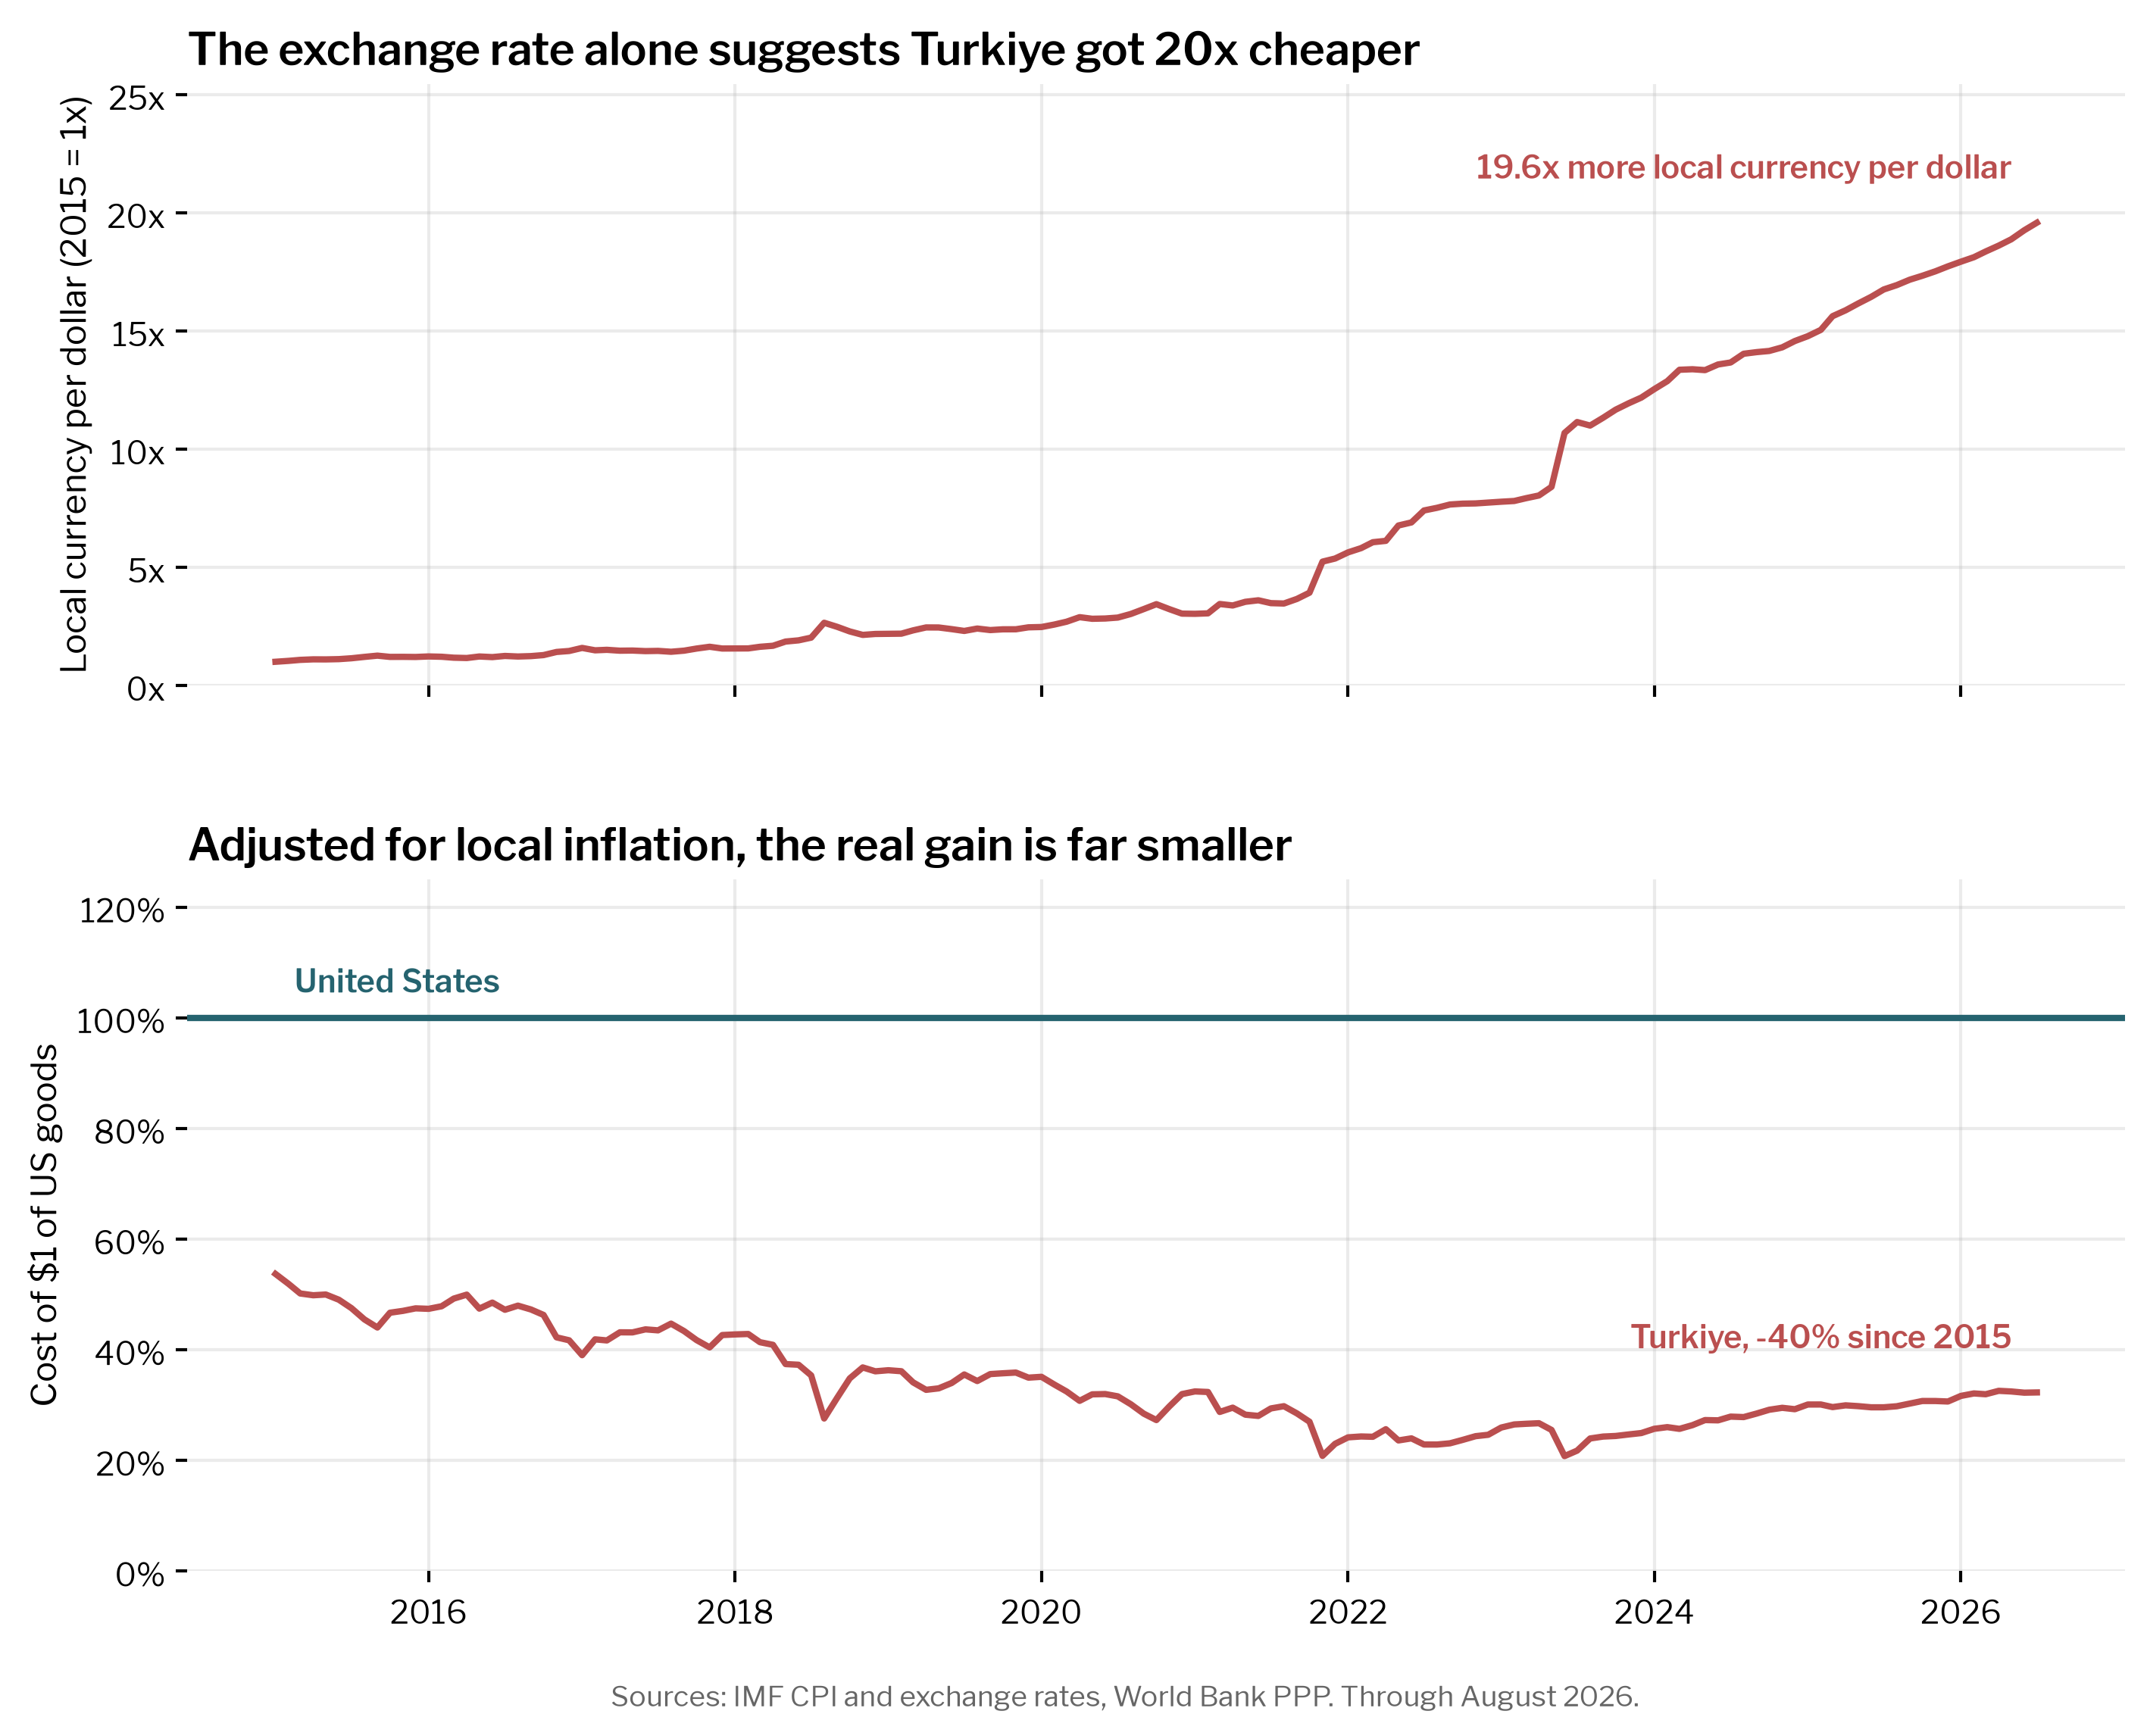

In [3]:
rtc.plot_devaluation_vs_real_cost(panel);

## Cheapest and most expensive today

Advisory levels 1-2 only. Countries report CPI on different lags, so each is shown at its
own latest month.

In [4]:
ranked = rtc.rank_latest(panel)

display(ranked.head(10))
display(ranked.tail(10))

,country_name,date,advisory_level,current_dollars
0,Egypt,2026-06-01,2,0.192396
1,Sri Lanka,2026-06-01,2,0.226272
2,Bhutan,2026-02-01,1,0.230260
3,Nepal,2026-03-01,2,0.234067
4,Indonesia,2026-07-01,2,0.236588
5,Lao People`s Democratic Republic,2026-06-01,2,0.239124
6,India,2026-07-01,2,0.239212
7,Uzbekistan,2026-05-01,1,0.251401
8,Tajikistan,2026-04-01,2,0.253117
9,Viet Nam,2026-06-01,1,0.279170


,country_name,date,advisory_level,current_dollars
93,Netherlands,2026-08-01,2,0.903485
94,Ireland,2026-07-01,1,0.904226
95,Finland,2026-07-01,1,0.905414
96,Luxembourg,2026-07-01,1,0.921657
97,United Kingdom,2026-07-01,2,0.942397
98,United States,2026-07-01,1,1.000000
99,Barbados,2026-06-01,1,1.013901
100,Norway,2026-07-01,1,1.049001
101,Switzerland,2026-07-01,1,1.180081
102,Iceland,2026-08-01,1,1.377021


## What has changed over the last decade?

Turkey is the case from the README: the lira lost most of its value, yet domestic inflation
cancelled nearly all of the gain a dollar holder might have expected.

In [5]:
changes = rtc.rank_change(panel, start="2015-07-01", end="2025-07-01")

print("Largest price increases:")
display(changes.head(10))
print("Largest price decreases:")
display(changes.tail(10))

Largest price increases:


,country_name,advisory_level,start,end,pct_change
0,Albania,2,0.326579,0.473057,0.448520
1,Serbia,2,0.373224,0.469595,0.258212
2,Estonia,1,0.591605,0.740385,0.251485
3,Lithuania,1,0.492329,0.603223,0.225245
4,Iceland,1,1.078345,1.319249,0.223401
5,Armenia,2,0.331697,0.397865,0.199485
6,Bulgaria,1,0.389131,0.462021,0.187314
7,Poland,1,0.470840,0.557443,0.183934
8,Latvia,1,0.535779,0.626158,0.168687
9,Slovakia,1,0.595574,0.683059,0.146891


Largest price decreases:


,country_name,advisory_level,start,end,pct_change
103,Malaysia,1,0.422976,0.331622,-0.215980
104,"Korea, Republic of",1,0.729015,0.556633,-0.236459
105,Brazil,2,0.612982,0.459914,-0.249710
106,Lao People`s Democratic Republic,2,0.337567,0.253223,-0.249859
107,Sri Lanka,2,0.331889,0.243515,-0.266276
108,Japan,1,0.870642,0.607837,-0.301852
109,Kazakhstan,1,0.542264,0.360644,-0.334929
110,Turkey,2,0.475204,0.295989,-0.377133
111,Egypt,2,0.323814,0.175113,-0.459219
112,Uzbekistan,1,0.509275,0.234545,-0.539454


## Coverage

Joins are on ISO-3 codes, except the State Dept. feed, which publishes names only. Anything
left unmatched below needs an entry in `countries.ADVISORY_NAME_TO_CODE`.

In [6]:
advisories = rtc.attach_country_codes(rtc.fetch_travel_advisories(), rtc.load_ppp())
rtc.unmatched(advisories)

0                               Andorra
1                            Antarctica
2                               Bonaire
3                British Virgin Islands
4                                Brunei
5                                 Burma
6                                  Cuba
7                              CuraÃ§ao
8                               Czechia
9        Federated States of Micronesia
10                        French Guiana
11                     French Polynesia
12                   French West Indies
13                                 Gaza
14                            Greenland
15                   Kingdom of Denmark
16                        Liechtenstein
17    Mainland China, Hong Kong & Macau
18               Mexico Travel Advisory
19                              Moldova
20                                Nauru
21                        New Caledonia
22                          North Korea
23                      North Macedonia
24                                 Saba
